# By the help of Grad-CAM and Integrated Gradients, investigate which area of an adversarial example of an image makes your favorite neural network confused.

# Integrated Gradients

In [1]:
import matplotlib.pylab as plt
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications.inception_v3 import InceptionV3, preprocess_input, decode_predictions

2025-06-28 13:30:01.991441: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1751095802.114909    9672 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1751095802.150697    9672 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1751095802.434291    9672 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1751095802.434360    9672 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1751095802.434365    9672 computation_placer.cc:177] computation placer alr

In [2]:
model = InceptionV3(include_top=True, weights='imagenet', input_shape=(299,299,3))
model.trainable = False
decode_predictions = decode_predictions
# model.summary()

W0000 00:00:1751095806.192375    9672 gpu_device.cc:2341] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [3]:
def preprocess_image(img_path):
    img = tf.keras.preprocessing.image.load_img(img_path, target_size=(299, 299))
    img = tf.keras.preprocessing.image.img_to_array(img)
    img = preprocess_input(img)
    return tf.expand_dims(img, 0) 

img = preprocess_image('Images/fireboat.jpg')

preds = model(img)
decoded = decode_predictions(preds.numpy(), top=5)[0]

for label, desc, score in decoded:
    print(f"{desc}: {score:.2%}")

fireboat: 69.65%
pier: 9.40%
suspension_bridge: 0.79%
fountain: 0.44%
steel_arch_bridge: 0.32%


In [4]:
img_name_tensors = {
    "Fireboat": tf.image.convert_image_dtype(
        tf.image.decode_jpeg(tf.io.read_file("Images/fireboat.jpg"), channels=3),
        dtype=tf.float32
    )
}

In [5]:
def top_k_predictions(img_tensor, k=5):
    
    img_resized = tf.image.resize(img_tensor, (299, 299)) 
    img_batch = tf.expand_dims(img_resized, 0)  
    img_preprocessed = preprocess_input(img_batch * 255.0)

    preds = model(img_preprocessed)
    decoded = decode_predictions(preds.numpy(), top=k)[0]  

    labels = [label for (_, label, _) in decoded]
    probs = [prob for (_, _, prob) in decoded]
    return labels, probs


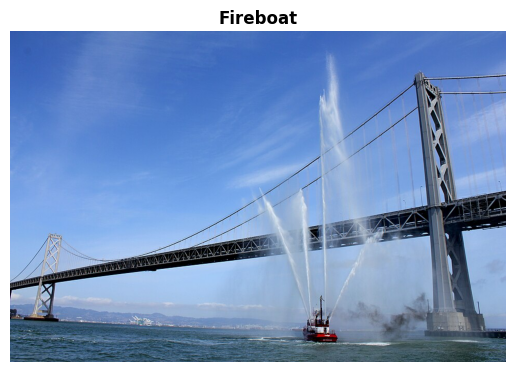

fireboat: 79.3%
pier: 5.9%
suspension_bridge: 0.5%
fountain: 0.4%
steel_arch_bridge: 0.2%


In [6]:
for name, img_tensor in img_name_tensors.items():
    plt.imshow(img_tensor)
    plt.title(name, fontweight='bold')
    plt.axis('off')
    plt.show()

    pred_label, pred_prob = top_k_predictions(img_tensor)
    for label, prob in zip(pred_label, pred_prob):
        print(f'{label}: {prob:0.1%}')


# Calculate Integrated Gradients

In [7]:
def f(x):
  """A simplified model function."""
  return tf.where(x < 0.8, x, 0.8)

def interpolated_path(x):
  """A straight line path."""
  return tf.zeros_like(x)

x = tf.linspace(start=0.0, stop=1.0, num=6)
y = f(x)

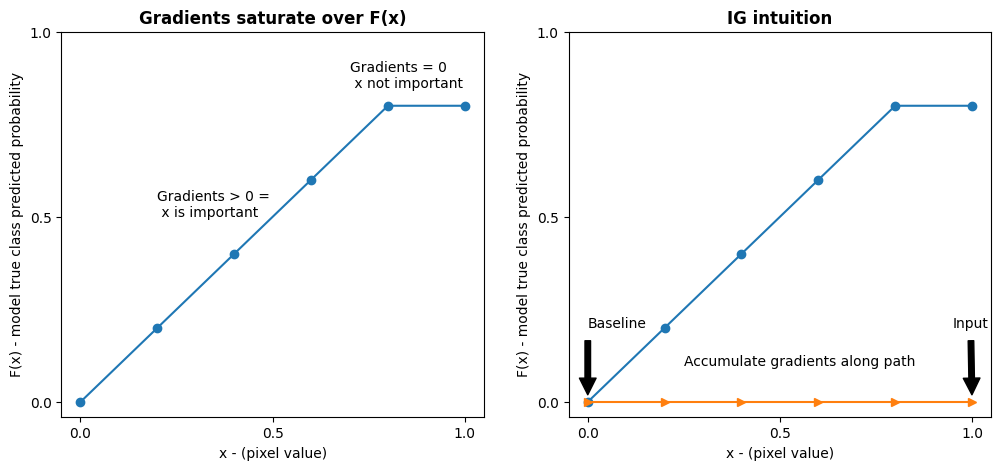

In [8]:
fig = plt.figure(figsize=(12, 5))
ax0 = fig.add_subplot(121)
ax0.plot(x, f(x), marker='o')
ax0.set_title('Gradients saturate over F(x)', fontweight='bold')
ax0.text(0.2, 0.5, 'Gradients > 0 = \n x is important')
ax0.text(0.7, 0.85, 'Gradients = 0 \n x not important')
ax0.set_yticks(tf.range(0, 1.5, 0.5))
ax0.set_xticks(tf.range(0, 1.5, 0.5))
ax0.set_ylabel('F(x) - model true class predicted probability')
ax0.set_xlabel('x - (pixel value)')

ax1 = fig.add_subplot(122)
ax1.plot(x, f(x), marker='o')
ax1.plot(x, interpolated_path(x), marker='>')
ax1.set_title('IG intuition', fontweight='bold')
ax1.text(0.25, 0.1, 'Accumulate gradients along path')
ax1.set_ylabel('F(x) - model true class predicted probability')
ax1.set_xlabel('x - (pixel value)')
ax1.set_yticks(tf.range(0, 1.5, 0.5))
ax1.set_xticks(tf.range(0, 1.5, 0.5))
ax1.annotate('Baseline', xy=(0.0, 0.0), xytext=(0.0, 0.2),
             arrowprops=dict(facecolor='black', shrink=0.1))
ax1.annotate('Input', xy=(1.0, 0.0), xytext=(0.95, 0.2),
             arrowprops=dict(facecolor='black', shrink=0.1))
plt.show()

In [9]:
baseline = tf.zeros(shape=(299,299,3))

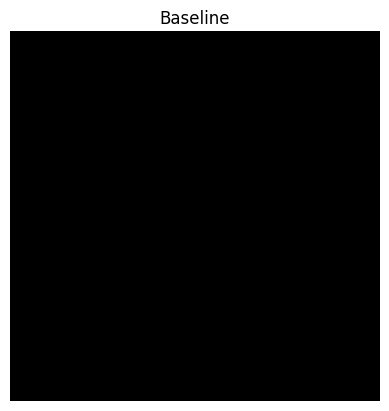

In [10]:
plt.imshow(baseline)
plt.title("Baseline")
plt.axis('off')
plt.show()

In [11]:
m_steps=50
alphas = tf.linspace(start=0.0, stop=1.0, num=m_steps+1) 

In [12]:
def interpolate_images(baseline,
                       image,
                       alphas):
  alphas_x = alphas[:, tf.newaxis, tf.newaxis, tf.newaxis]
  baseline_x = tf.expand_dims(baseline, axis=0)
  input_x = tf.expand_dims(image, axis=0)
  delta = input_x - baseline_x
  images = baseline_x +  alphas_x * delta
  return images

In [13]:
print(img_name_tensors.keys())

dict_keys(['Fireboat'])


In [14]:
img = tf.image.resize(img_name_tensors['Fireboat'], size=(299,299))
interpolated_images = interpolate_images(
    baseline=baseline,
    image=img,
    alphas=alphas)

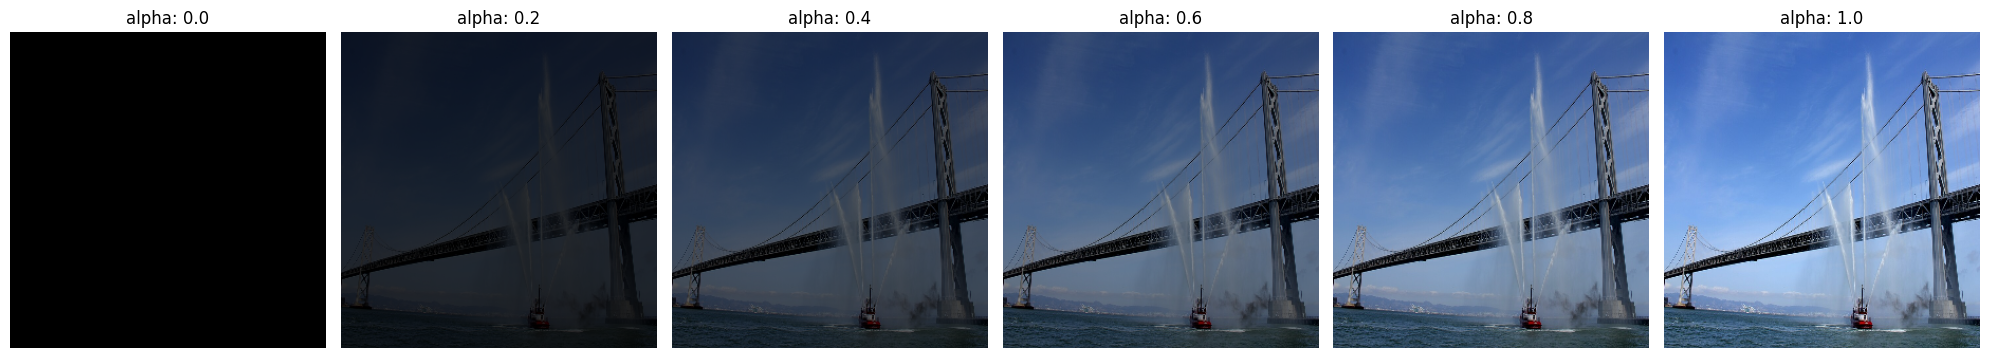

In [15]:
fig = plt.figure(figsize=(20, 20))

i = 0
for alpha, image in zip(alphas[0::10], interpolated_images[0::10]):
  i += 1
  plt.subplot(1, len(alphas[0::10]), i)
  plt.title(f'alpha: {alpha:.1f}')
  plt.imshow(image)
  plt.axis('off')

plt.tight_layout()

In [16]:
def compute_gradients(images, target_class_idx):
  with tf.GradientTape() as tape:
    tape.watch(images)
    logits = model(images)
    probs = tf.nn.softmax(logits, axis=-1)[:, target_class_idx]
  return tape.gradient(probs, images)

In [17]:
path_gradients = compute_gradients(
    images=interpolated_images,
    target_class_idx=555)

In [18]:
pred = model(interpolated_images)
pred_proba = tf.nn.softmax(pred, axis=-1)[:, 555]

(0.0, 1.0)

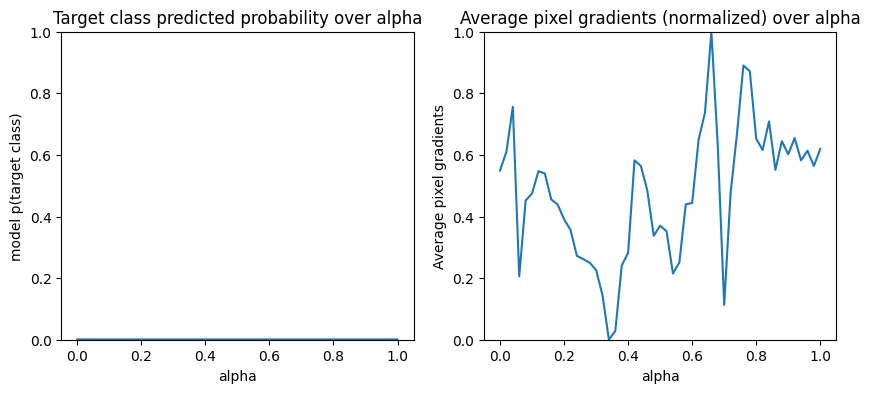

In [ ]:
plt.figure(figsize=(10, 4))
ax1 = plt.subplot(1, 2, 1)
ax1.plot(alphas, pred_proba)
ax1.set_title('Target class predicted probability over alpha')
ax1.set_ylabel('model p(target class)')
ax1.set_xlabel('alpha')
ax1.set_ylim([0, 1])

ax2 = plt.subplot(1, 2, 2)
# Average across interpolation steps
average_grads = tf.reduce_mean(path_gradients, axis=[1, 2, 3])
# Normalize gradients to 0 to 1 scale. E.g., (x - min(x))/(max(x)-min(x))
average_grads_norm = (average_grads-tf.math.reduce_min(average_grads))/(tf.math.reduce_max(average_grads)-tf.reduce_min(average_grads))
ax2.plot(alphas, average_grads_norm)
ax2.set_title('Average pixel gradients (normalized) over alpha')
ax2.set_ylabel('Average pixel gradients')
ax2.set_xlabel('alpha')
ax2.set_ylim([0, 1])

In [ ]:
def integral_approximation(gradients):
  grads = (gradients[:-1] + gradients[1:]) / tf.constant(2.0)
  integrated_gradients = tf.math.reduce_mean(grads, axis=0)
  return integrated_gradients

In [21]:
ig = integral_approximation(
    gradients=path_gradients)

In [22]:
print(ig.shape)

(299, 299, 3)


In [ ]:
def integrated_gradients(baseline,
                         image,
                         target_class_idx,
                         m_steps=50,
                         batch_size=32):
  alphas = tf.linspace(start=0.0, stop=1.0, num=m_steps+1)

  gradient_batches = []

  for alpha in tf.range(0, len(alphas), batch_size):
    from_ = alpha
    to = tf.minimum(from_ + batch_size, len(alphas))
    alpha_batch = alphas[from_:to]

    gradient_batch = one_batch(baseline, image, alpha_batch, target_class_idx)
    gradient_batches.append(gradient_batch)

  total_gradients = tf.concat(gradient_batches, axis=0)

  avg_gradients = integral_approximation(gradients=total_gradients)

  integrated_gradients = (image - baseline) * avg_gradients

  return integrated_gradients

In [ ]:
@tf.function
def one_batch(baseline, image, alpha_batch, target_class_idx):
    interpolated_path_input_batch = interpolate_images(baseline=baseline,
                                                       image=image,
                                                       alphas=alpha_batch)

    gradient_batch = compute_gradients(images=interpolated_path_input_batch,
                                       target_class_idx=target_class_idx)
    return gradient_batch

In [25]:
ig_attributions = integrated_gradients(baseline=baseline,
                                       image=img,
                                       target_class_idx=555,
                                       m_steps=240)

In [26]:
print(ig_attributions.shape)

(299, 299, 3)


In [ ]:
def plot_img_attributions(baseline,
                          image,
                          target_class_idx,
                          m_steps=50,
                          cmap=None,
                          overlay_alpha=0.4):

  attributions = integrated_gradients(baseline=baseline,
                                      image=image,
                                      target_class_idx=target_class_idx,
                                      m_steps=m_steps)

  attribution_mask = tf.reduce_sum(tf.math.abs(attributions), axis=-1)

  fig, axs = plt.subplots(nrows=2, ncols=2, squeeze=False, figsize=(8, 8))

  axs[0, 0].set_title('Baseline image')
  axs[0, 0].imshow(baseline)
  axs[0, 0].axis('off')

  axs[0, 1].set_title('Original image')
  axs[0, 1].imshow(image)
  axs[0, 1].axis('off')

  axs[1, 0].set_title('Attribution mask')
  axs[1, 0].imshow(attribution_mask, cmap=cmap)
  axs[1, 0].axis('off')

  axs[1, 1].set_title('Overlay')
  axs[1, 1].imshow(attribution_mask, cmap=cmap)
  axs[1, 1].imshow(image, alpha=overlay_alpha)
  axs[1, 1].axis('off')

  plt.tight_layout()
  return fig

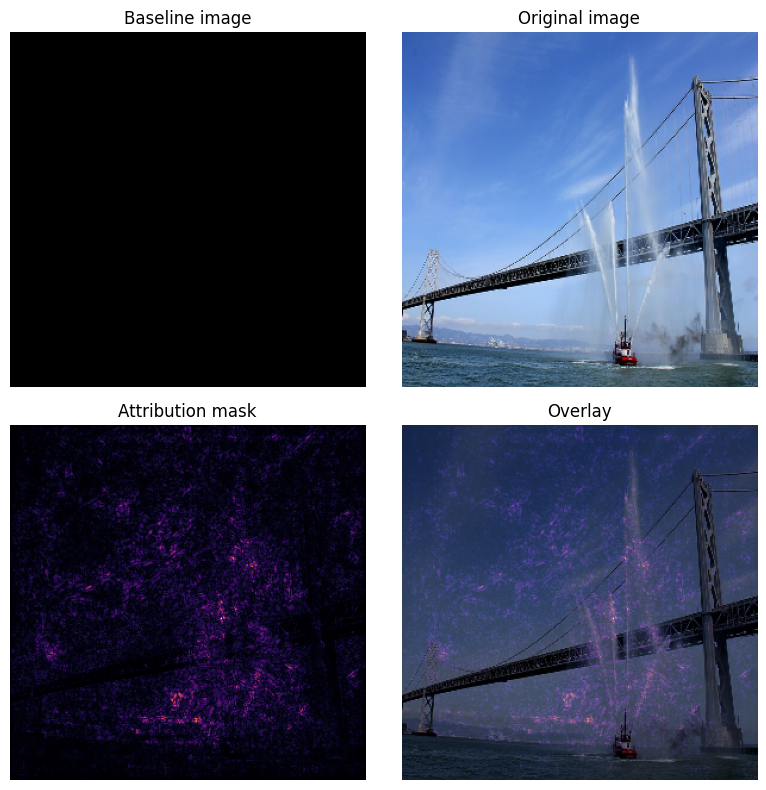

In [28]:
_ = plot_img_attributions(image=img,
                          baseline=baseline,
                          target_class_idx=555,
                          m_steps=240,
                          cmap=plt.cm.inferno,
                          overlay_alpha=0.4)

# Grad-CAM

In [29]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications.inception_resnet_v2 import InceptionResNetV2, preprocess_input, decode_predictions
import matplotlib.pyplot as plt

In [30]:
model = InceptionResNetV2(include_top=True, weights="imagenet")

In [31]:
preprocess_input = preprocess_input
decode_predictions = decode_predictions
last_conv_layer_name = "conv_7b_ac"

In [32]:
def display_image(image):
    # print(image.shape)
    
    plt.figure(figsize=(12,8))
    plt.imshow(image)
    plt.axis('off')
    plt.show()

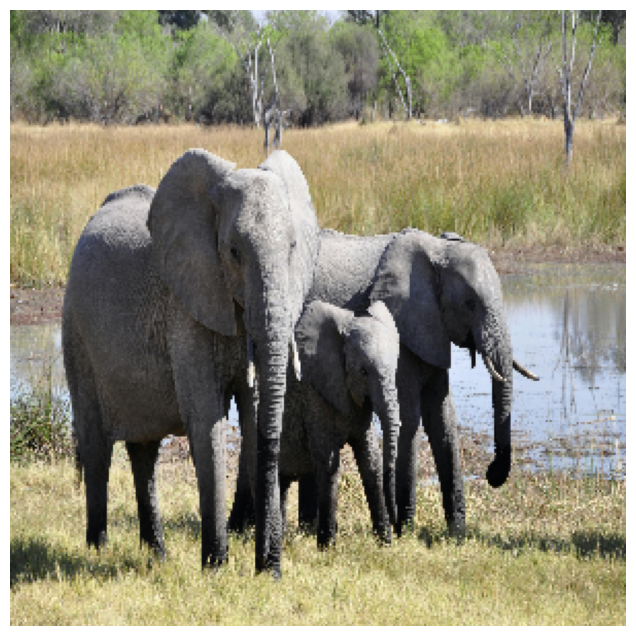

In [54]:
import cv2
img_path = "Images/elephant.jpg"
image = cv2.imread(img_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
image = cv2.resize(image, (299, 299))
display_image(image)


In [55]:
image_array = tf.keras.utils.img_to_array(image)
image_array = np.expand_dims(image_array, axis=0)
image_array = preprocess_input(image_array)
print(image_array)

[[[[-0.49019605 -0.3960784  -0.5529412 ]
   [-0.40392154 -0.2862745  -0.47450978]
   [-0.27058822 -0.14509803 -0.52156866]
   ...
   [-0.5058824  -0.47450978 -0.42745095]
   [-0.6        -0.5686275  -0.58431375]
   [-0.49019605 -0.47450978 -0.4823529 ]]

  [[-0.4352941  -0.34117645 -0.5294118 ]
   [-0.3098039  -0.12941176 -0.4980392 ]
   [-0.23921567 -0.11372548 -0.49019605]
   ...
   [-0.40392154 -0.35686272 -0.41176468]
   [-0.5764706  -0.5137255  -0.5058824 ]
   [-0.58431375 -0.5686275  -0.58431375]]

  [[-0.35686272 -0.21568626 -0.54509807]
   [-0.47450978 -0.31764704 -0.6392157 ]
   [-0.25490195 -0.10588235 -0.46666664]
   ...
   [-0.40392154 -0.38823527 -0.42745095]
   [-0.6392157  -0.62352943 -0.6313726 ]
   [-0.6392157  -0.6392157  -0.6156863 ]]

  ...

  [[ 0.47450984  0.35686278  0.15294123]
   [ 0.5764706   0.4431373   0.09803927]
   [ 0.4039216   0.2941177  -0.06666666]
   ...
   [ 0.5529412   0.4431373   0.09803927]
   [ 0.427451    0.2941177  -0.11372548]
   [ 0.4431373  

In [56]:
model.layers[-1].activation = None

In [125]:
preds = model.predict(image_array)
print(f"Predicted : ", decode_predictions(preds, top=5)[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Predicted :  [('n02109961', 'Eskimo_dog', np.float32(0.09303502)), ('n02110185', 'Siberian_husky', np.float32(0.064657085)), ('n02127052', 'lynx', np.float32(0.046374198)), ('n02115641', 'dingo', np.float32(0.039773643)), ('n02124075', 'Egyptian_cat', np.float32(0.032821458))]


In [58]:
def make_gradcam_heatmap(img_array, model, last_layer, pred_index=None):
    grad_model = tf.keras.models.Model(
        model.input, [model.get_layer(last_layer).output, model.output]
    )

    with tf.GradientTape() as tape:
        last_layer_output, preds = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]
    grads = tape.gradient(class_channel, last_layer_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))

    last_layer_output = last_layer_output[0]
    heatmap = last_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap,0)/tf.math.reduce_max(heatmap)

    return heatmap.numpy()

# Rough

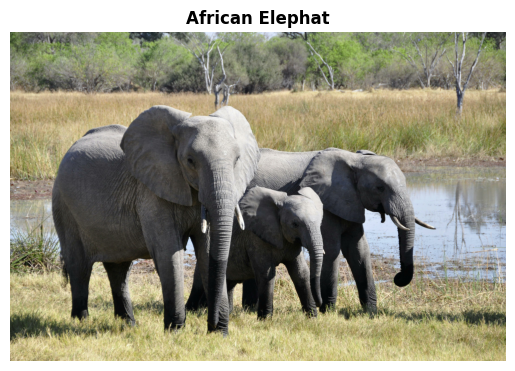

African_elephant: 78.2%
tusker: 15.2%
Indian_elephant: 0.5%
zebra: 0.0%
ladle: 0.0%


In [128]:
img_name_tensors = {
    "African Elephat": tf.image.convert_image_dtype(
        tf.image.decode_jpeg(tf.io.read_file("Images/elephant.jpg"), channels=3),
        dtype=tf.float32
    )
}
for name, img_tensor in img_name_tensors.items():
    plt.imshow(img_tensor)
    plt.title(name, fontweight='bold')
    plt.axis('off')
    plt.show()

    pred_label, pred_prob = top_k_predictions(img_tensor)
    for label, prob in zip(pred_label, pred_prob):
        print(f'{label}: {prob:0.1%}')

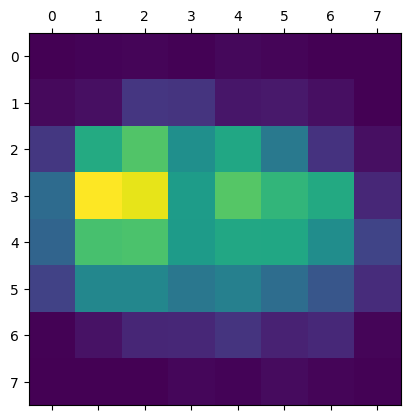

In [59]:
heatmap = make_gradcam_heatmap(image_array, model, last_conv_layer_name)
plt.matshow(heatmap)
plt.show()

In [60]:
def save_and_display_gradcam(img_path, heatmap, cam_path="cam.jpg", alpha=0.4):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  

    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))

    heatmap = np.uint8(255 * heatmap)

    heatmap_color = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)

    superimposed_img = cv2.addWeighted(img, 1 - alpha, heatmap_color, alpha, 0)

    cv2.imwrite(cam_path, cv2.cvtColor(superimposed_img, cv2.COLOR_RGB2BGR))  
    plt.imshow(superimposed_img)
    plt.axis('off')
    plt.title("Grad-CAM")
    plt.show()

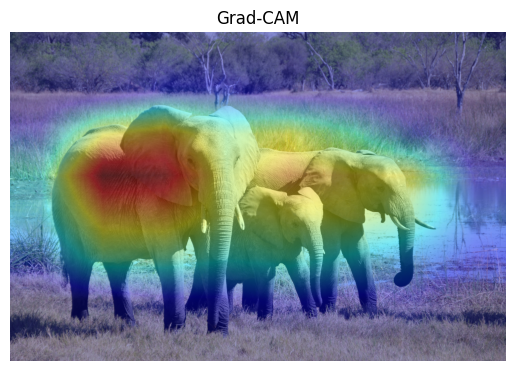

In [61]:
save_and_display_gradcam(img_path, heatmap)

In [62]:
import cv2
img_path = "Images/cats_dogs.jpeg"
image = cv2.imread(img_path, cv2.COLOR_BGR2RGB)
image = cv2.resize(image, (299,299))
# display_image(image)
image_array = tf.keras.utils.img_to_array(image)
image_array = np.expand_dims(image_array, axis=0)
image_array = preprocess_input(image_array)
# print(image_array)
preds = model.predict(image_array)
print(f"Predicted : ", decode_predictions(preds, top=5)[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step
Predicted :  [('n02123045', 'tabby', np.float32(6.1479526)), ('n02093428', 'American_Staffordshire_terrier', np.float32(5.9160075)), ('n02127052', 'lynx', np.float32(5.866734)), ('n02124075', 'Egyptian_cat', np.float32(5.554454)), ('n02123159', 'tiger_cat', np.float32(5.5059814))]


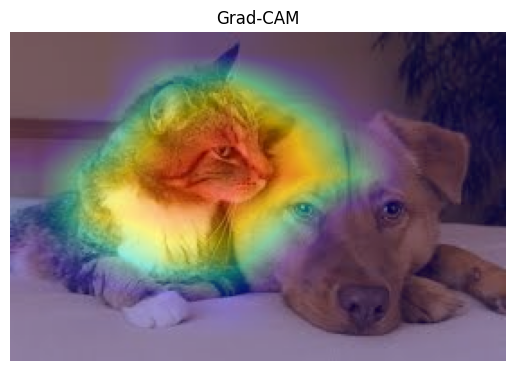

In [63]:
heatmap = make_gradcam_heatmap(image_array, model, last_conv_layer_name)
save_and_display_gradcam(img_path, heatmap)

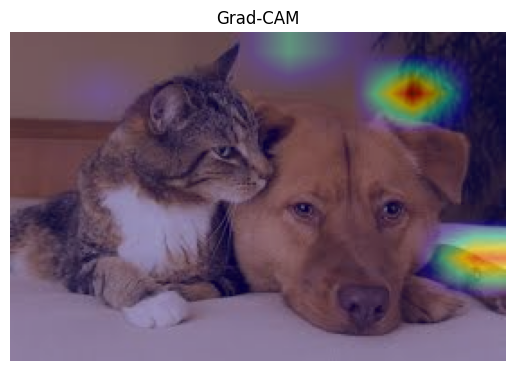

In [64]:
heatmap = make_gradcam_heatmap(image_array, model, last_conv_layer_name, pred_index=28)
save_and_display_gradcam(img_path, heatmap)

# Compare most important area of an adversarial example with the important area of the original image.

# FGSM

In [ ]:
def generate_adversarial(model, image, label, epsilon=0.01):
    image = tf.convert_to_tensor(image[None, ...])  
    label = tf.one_hot(label, 1000)[None, ...]       

    with tf.GradientTape() as tape:
        tape.watch(image)
        prediction = model(image)
        loss = tf.keras.losses.categorical_crossentropy(label, prediction)

    gradient = tape.gradient(loss, image)
    signed_grad = tf.sign(gradient)
    adversarial = image + epsilon * signed_grad
    adversarial = tf.clip_by_value(adversarial, 0, 1)
    return adversarial[0]


# Grad-CAM

In [71]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.applications.inception_v3 import preprocess_input, decode_predictions

In [76]:
model = InceptionV3(weights="imagenet")
model.trainable = False

In [72]:
def load_image(path, target_size=(299, 299)):
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, target_size)
    img = preprocess_input(img.astype(np.float32))
    return img

In [73]:
def generate_adversarial(model, image, label, epsilon=0.01):
    image = tf.convert_to_tensor(image[None, ...])
    label = tf.one_hot(label, 1000)[None, ...]
    with tf.GradientTape() as tape:
        tape.watch(image)
        prediction = model(image)
        loss = tf.keras.losses.categorical_crossentropy(label, prediction)
    gradient = tape.gradient(loss, image)
    signed_grad = tf.sign(gradient)
    adversarial = image + epsilon * signed_grad
    return tf.clip_by_value(adversarial[0], -1, 1).numpy()

In [74]:
def make_gradcam_heatmap(img_array, model, layer_name="mixed10"):
    grad_model = tf.keras.models.Model(
        [model.inputs], [model.get_layer(layer_name).output, model.output]
    )
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(tf.expand_dims(img_array, 0))
        class_idx = tf.argmax(predictions[0])
        loss = predictions[:, class_idx]
    grads = tape.gradient(loss, conv_outputs)[0]
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy(), class_idx

In [75]:
def overlay_heatmap(original, heatmap, alpha=0.4):
    heatmap_resized = cv2.resize(heatmap, (original.shape[1], original.shape[0]))

    heatmap_uint8 = np.uint8(255 * heatmap_resized)
    heatmap_color = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
    heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)

    overlay = heatmap_color * alpha + original
    return np.uint8(np.clip(overlay, 0, 255))

In [92]:
image_path = "Images/elephant.jpg"  
orig_img = cv2.imread(image_path)
orig_img_rgb = cv2.cvtColor(orig_img, cv2.COLOR_BGR2RGB)
orig_img_resized = cv2.resize(orig_img_rgb, (299, 299))
image = preprocess_input(orig_img_resized.astype(np.float32))

In [93]:
preds = model.predict(image[None, ...])
label_index = np.argmax(preds)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step


In [94]:
adv_image = generate_adversarial(model, image, label_index)

In [95]:
heatmap_orig, _ = make_gradcam_heatmap(image, model)
heatmap_adv, _ = make_gradcam_heatmap(adv_image, model)

/home/cse/Desktop/Miju_work/tf-env-py311/lib/python3.11/site-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor_1721']]
Received: inputs=['Tensor(shape=(1, 299, 299, 3))']
  warnings.warn(msg)


In [96]:
overlay_orig = overlay_heatmap(orig_img_resized, heatmap_orig)
overlay_adv = overlay_heatmap(orig_img_resized, heatmap_adv)

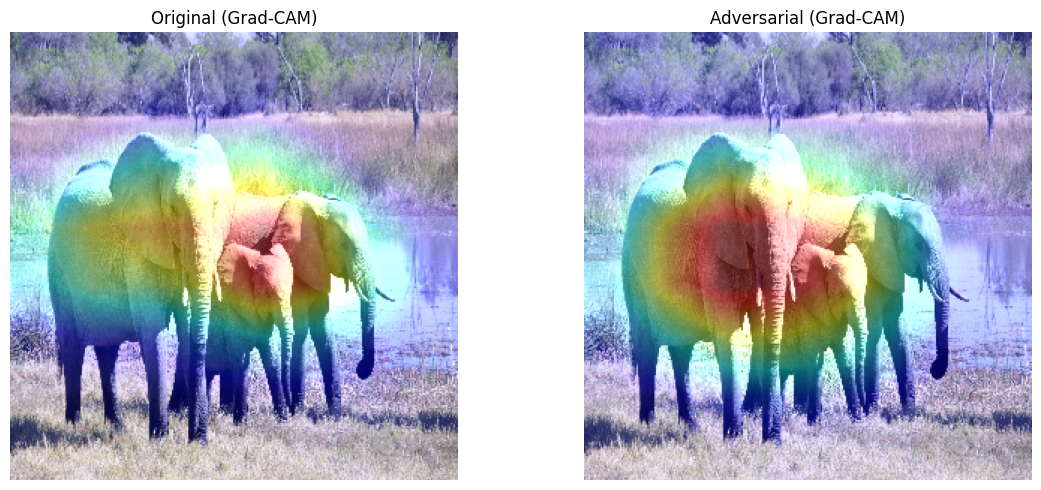

In [97]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.title("Original (Grad-CAM)")
plt.imshow(overlay_orig)
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("Adversarial (Grad-CAM)")
plt.imshow(overlay_adv)
plt.axis('off')

plt.tight_layout()
plt.show()

# Investigate what will happen if you consider softmax layer for Grad-CAM and the previous-layer of the softmax layer for IG for estimating gradients.

In [99]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import cv2
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.applications.inception_v3 import preprocess_input

In [107]:
model = InceptionV3(weights="imagenet")
model_logits = tf.keras.Model(inputs=model.input, outputs=model.layers[-1].input)
model_softmax = tf.keras.Model(inputs=model.input, outputs=model.output)

In [100]:
def load_image(path, target_size=(299, 299)):
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, target_size)
    img_processed = preprocess_input(img.astype(np.float32))
    return img_processed, img

In [101]:
def compute_gradcam(image, model, class_idx, layer_name='mixed10'):
    grad_model = tf.keras.models.Model(
        [model.inputs], [model.get_layer(layer_name).output, model.output]
    )
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(tf.expand_dims(image, 0))
        loss = predictions[:, class_idx]
    grads = tape.gradient(loss, conv_outputs)[0]
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap + 1e-10)
    return heatmap.numpy()

In [102]:
def interpolate_images(baseline, image, alphas):
    alphas_x = alphas[:, tf.newaxis, tf.newaxis, tf.newaxis]
    delta = image - baseline
    return baseline + alphas_x * delta

In [103]:
def compute_integrated_gradients(image, model, class_index, baseline=None, steps=50):
    if baseline is None:
        baseline = np.zeros_like(image).astype(np.float32)
    alphas = tf.linspace(0.0, 1.0, steps)
    interpolated = interpolate_images(baseline, image, alphas)
    with tf.GradientTape() as tape:
        tape.watch(interpolated)
        preds = model(interpolated)
        probs = preds[:, class_index]
    grads = tape.gradient(probs, interpolated)
    avg_grads = tf.reduce_mean(grads, axis=0).numpy()
    ig = (image - baseline) * avg_grads
    ig = np.sum(np.abs(ig), axis=-1)
    return ig / np.max(ig + 1e-10)

In [104]:
def overlay_heatmap(image, heatmap, alpha=0.4):
    heatmap = cv2.resize(heatmap, (image.shape[1], image.shape[0]))
    heatmap_uint8 = np.uint8(255 * heatmap)
    heatmap_color = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
    heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)
    overlay = heatmap_color * alpha + image
    return np.uint8(np.clip(overlay, 0, 255))

In [105]:
def plot_comparisons(original, cam_softmax, cam_logits, ig_map):
    fig, axs = plt.subplots(1, 4, figsize=(20, 6))
    axs[0].imshow(original)
    axs[0].set_title("Original")
    axs[1].imshow(cam_softmax)
    axs[1].set_title("Grad-CAM (Softmax)")
    axs[2].imshow(cam_logits)
    axs[2].set_title("Grad-CAM (Logits)")
    axs[3].imshow(ig_map, cmap='hot')
    axs[3].set_title("Integrated Gradients")
    for ax in axs:
        ax.axis('off')
    plt.tight_layout()
    plt.show()

In [119]:
img_path = "Images/elephant.jpg" 
image, display_image = load_image(img_path)

In [120]:
pred = model_softmax(tf.expand_dims(image, 0))
class_idx = tf.argmax(pred[0]).numpy()

In [121]:
cam_softmax = compute_gradcam(image, model_softmax, class_idx)
cam_logits = compute_gradcam(image, model_logits, class_idx)

/home/cse/Desktop/Miju_work/tf-env-py311/lib/python3.11/site-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor_2347']]
Received: inputs=['Tensor(shape=(1, 299, 299, 3))']
  warnings.warn(msg)


In [122]:
ig_map = compute_integrated_gradients(image, model_logits, class_idx)

In [123]:
cam_softmax_overlay = overlay_heatmap(display_image, cam_softmax)
cam_logits_overlay = overlay_heatmap(display_image, cam_logits)

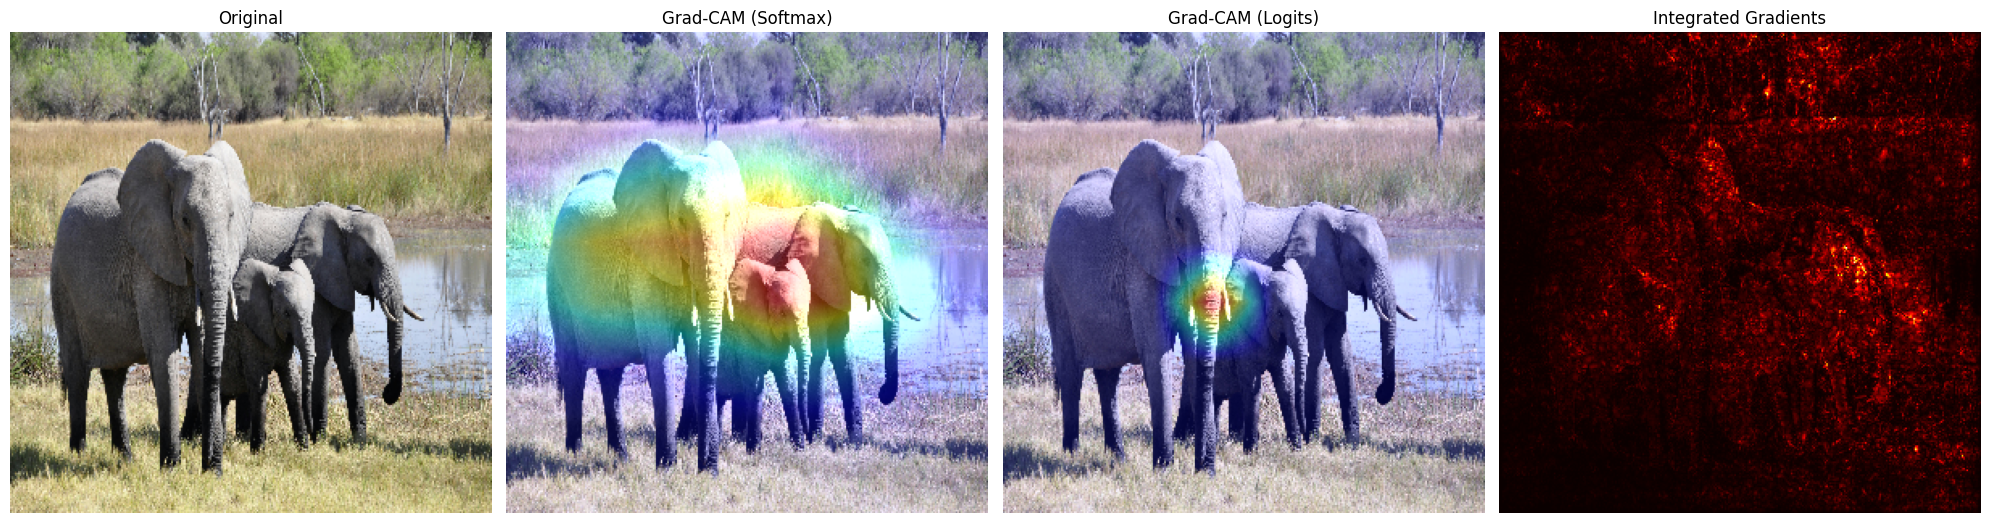

In [124]:
plot_comparisons(display_image, cam_softmax_overlay, cam_logits_overlay, ig_map)